# Kinematic Preprocessing

Now that we have the data generated in Matlab, we will enrich it further by adding variables that have proven to be useful in previous studies.

## 1. Additional features:

### 1.1 Pelvis Tilt
Pelvis Tilt -> Direct

### 1.2 Joint Resultant Force at HS
Joint resultant force at HS -> Ground Reaction Forces -> Inverse Dynamics

### 1.3 Ankle, Knee, Hip in Flexion/Extension, Abduction/Adduction, Plus Varus/Plantarflex
ankle, knee, hip in flexion/extension, abduction/adduction, plus varus/plantarflex

### 1.4 Kinetic Moments
Kinetic Moments -> Ground Reaction Forces -> Inverse Dynamics

### 1.5 Upper and Lower Envelope Angles
Upper and lower envelope angles -> Direct

In [1]:
from core.matlab_data_loader import MatlabDataLoader
from core.markers import visualize_marker_trajectories
import kineticstoolkit as ktk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
loader = MatlabDataLoader()

first_session_id = loader.get_successful_sessions()[0]
print("First session id: ", first_session_id)

L_KNEE_MARKER = "L_shank_1"
L_KNEE_JOINT = "L_knee"

# Raw
l_shank_1_marker_data = loader.get_marker_data(first_session_id, L_KNEE_MARKER)
l_knee_angle_data = loader.get_joint_angles(first_session_id, L_KNEE_JOINT, normalized=False)
l_knee_velocity_data = loader.get_joint_velocities(first_session_id, L_KNEE_JOINT, normalized=False)

# Normalised
l_knee_normalized_angle_data = loader.get_joint_angles(first_session_id, L_KNEE_JOINT, normalized=True)
l_knee_normalized_velocity_data = loader.get_joint_velocities(first_session_id, L_KNEE_JOINT, normalized=True)

First session id:  100001_20110531T161051


In [3]:
print("Shapes")
print("l_shank_1_marker_data: ", l_shank_1_marker_data.shape)
print("l_knee_angle_data: ", l_knee_angle_data.shape)
print("l_knee_velocity_data: ", l_knee_velocity_data.shape)
print("l_knee_normalized_angle_data: ", l_knee_normalized_angle_data.shape)
print("l_knee_normalized_velocity_data: ", l_knee_normalized_velocity_data.shape)

print("Columns")
print("l_shank_1_marker_data: ", l_shank_1_marker_data.columns)
print("l_knee_angle_data: ", l_knee_angle_data.columns)
print("l_knee_velocity_data: ", l_knee_velocity_data.columns)
print("l_knee_normalized_angle_data: ", l_knee_normalized_angle_data.columns)
print("l_knee_normalized_velocity_data: ", l_knee_normalized_velocity_data.columns)

print("First rows")
print("l_shank_1_marker_data: ", l_shank_1_marker_data.head())
print("l_knee_angle_data: ", l_knee_angle_data.head())
print("l_knee_velocity_data: ", l_knee_velocity_data.head())
print("l_knee_normalized_angle_data: ", l_knee_normalized_angle_data.head())
print("l_knee_normalized_velocity_data: ", l_knee_normalized_velocity_data.head())

Shapes
l_shank_1_marker_data:  (4000, 4)
l_knee_angle_data:  (4000, 4)
l_knee_velocity_data:  (3999, 4)
l_knee_normalized_angle_data:  (101, 4)
l_knee_normalized_velocity_data:  (101, 4)
Columns
l_shank_1_marker_data:  Index(['TimeIndex', 'X_coord', 'Y_coord', 'Z_coord'], dtype='object')
l_knee_angle_data:  Index(['TimeIndex', 'X_deg', 'Y_deg', 'Z_deg'], dtype='object')
l_knee_velocity_data:  Index(['TimeIndex', 'X_deg_per_s', 'Y_deg_per_s', 'Z_deg_per_s'], dtype='object')
l_knee_normalized_angle_data:  Index(['PercentGaitCycle', 'X_deg', 'Y_deg', 'Z_deg'], dtype='object')
l_knee_normalized_velocity_data:  Index(['PercentGaitCycle', 'X_deg_per_s', 'Y_deg_per_s', 'Z_deg_per_s'], dtype='object')
First rows
l_shank_1_marker_data:     TimeIndex     X_coord     Y_coord     Z_coord
0          1 -356.669861  331.622173 -238.005297
1          2 -356.671561  333.842239 -237.418668
2          3 -356.659899  336.112246 -236.900003
3          4 -356.628951  338.406509 -236.501722
4          5 -356

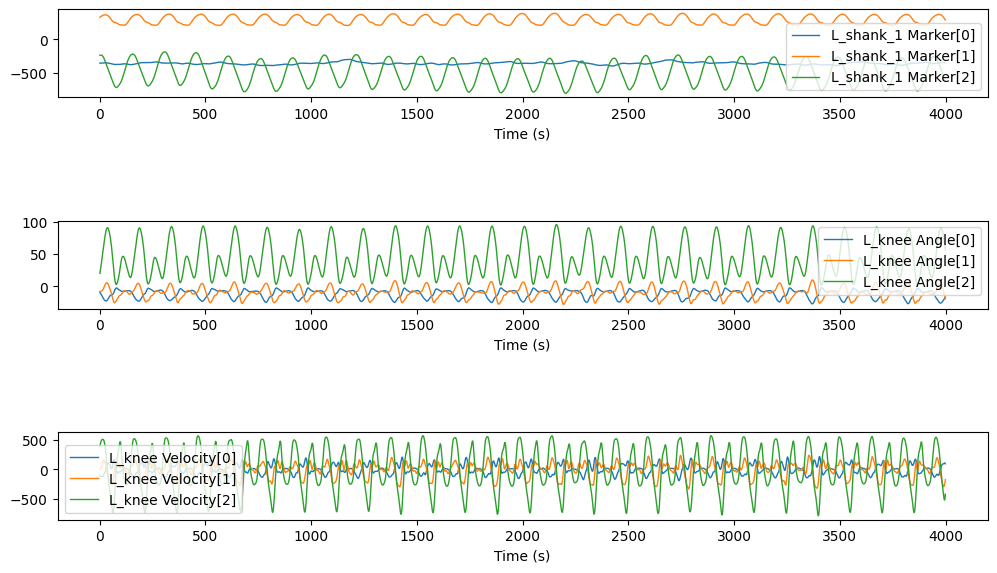

In [4]:
ts = ktk.TimeSeries()

ts.time = l_shank_1_marker_data['TimeIndex'][:3999]  # velocity has 1 frame less.
ts.units = "frames"

# Raw
ts = ts.add_data("L_shank_1 Marker", l_shank_1_marker_data.values[:3999,1:])
ts = ts.add_data("L_knee Angle", l_knee_angle_data.values[:3999,1:])
ts = ts.add_data("L_knee Velocity", l_knee_velocity_data.values[:3999,1:])

plt.figure(figsize=(12, 8))
plt.subplot(6, 1, 1)
ts.plot("L_shank_1 Marker")
plt.subplot(6, 1, 3)
ts.plot("L_knee Angle")
plt.subplot(6, 1, 5)
ts.plot("L_knee Velocity")
plt.show()

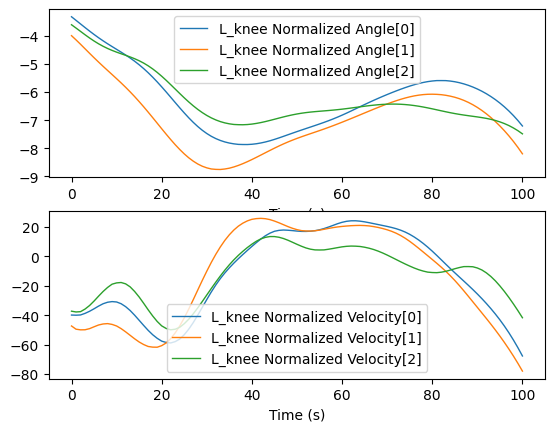

In [5]:
# Normalised
norm_ts = ktk.TimeSeries()
norm_ts.time = l_knee_normalized_angle_data.index
norm_ts = norm_ts.add_data("L_knee Normalized Angle", l_knee_normalized_angle_data.values[:,1:])
norm_ts = norm_ts.add_data("L_knee Normalized Velocity", l_knee_normalized_velocity_data.values[:,1:])

plt.subplot(2, 1, 1)
norm_ts.plot("L_knee Normalized Angle")
plt.subplot(2, 1, 2)
norm_ts.plot("L_knee Normalized Velocity")
plt.show()

In [6]:
# Get first session and explore available joints
first_session_id = loader.get_successful_sessions()[0]
print(f"First session ID: {first_session_id}")

# Get available joints
available_joints = loader.get_available_joints(first_session_id)
print(f"Available joints: {available_joints}")
print(f"Number of joints: {len(available_joints)}")

# Get session info for comprehensive overview
session_info = loader.get_session_info(first_session_id)
print(f"\nSession info: {session_info}")

First session ID: 100001_20110531T161051
Available joints: ['L_ankle', 'L_foot', 'L_hip', 'L_knee', 'L_pelvis', 'R_ankle', 'R_foot', 'R_hip', 'R_knee', 'R_pelvis', 'pelvis']
Number of joints: 11

Session info: {'session_id': '100001_20110531T161051', 'folder_path': '/Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/processed_data/matlab_output/100001_20110531T161051', 'available_joints': ['L_ankle', 'L_foot', 'L_hip', 'L_knee', 'L_pelvis', 'R_ankle', 'R_foot', 'R_hip', 'R_knee', 'R_pelvis', 'pelvis'], 'available_markers': ['L_foot_1', 'L_foot_2', 'L_foot_3', 'L_foot_4', 'L_shank_1', 'L_shank_2', 'L_shank_3', 'L_shank_4', 'L_thigh_1', 'L_thigh_2', 'L_thigh_3', 'L_thigh_4', 'L_toe', 'R_foot_1', 'R_foot_2', 'R_foot_3', 'R_foot_4', 'R_shank_1', 'R_shank_2', 'R_shank_3', 'R_shank_4', 'R_thigh_1', 'R_thigh_2', 'R_thigh_3', 'R_thigh_4', 'R_toe', 'pelvis_1', 'pelvis_2', 'pelvis_3', 'pelvis_4'], 'has_gait_events': True, 'has_joint_centers': True, 'has_

In [7]:
# Load all normalized angles and velocities for the first session
normalized_angles = loader.get_all_joint_angles(first_session_id, normalized=True)
normalized_velocities = loader.get_all_joint_velocities(first_session_id, normalized=True)

print(f"Loaded normalized angles for {len(normalized_angles)} joints")
print(f"Loaded normalized velocities for {len(normalized_velocities)} joints")

# Show what joints we have data for
print(f"\nAngles available for joints: {list(normalized_angles.keys())}")
print(f"Velocities available for joints: {list(normalized_velocities.keys())}")

# Check if angles and velocities have the same joints
common_joints = set(normalized_angles.keys()) & set(normalized_velocities.keys())
print(f"\nJoints with both angles and velocities: {sorted(common_joints)}")
print(f"Number of joints with complete data: {len(common_joints)}")


Loaded normalized angles for 10 joints
Loaded normalized velocities for 8 joints

Angles available for joints: ['R_pelvis', 'R_ankle', 'R_foot', 'L_foot', 'L_hip', 'L_knee', 'R_knee', 'L_pelvis', 'L_ankle', 'R_hip']
Velocities available for joints: ['L_hip', 'R_knee', 'R_hip', 'R_pelvis', 'R_ankle', 'L_pelvis', 'L_knee', 'L_ankle']

Joints with both angles and velocities: ['L_ankle', 'L_hip', 'L_knee', 'L_pelvis', 'R_ankle', 'R_hip', 'R_knee', 'R_pelvis']
Number of joints with complete data: 8


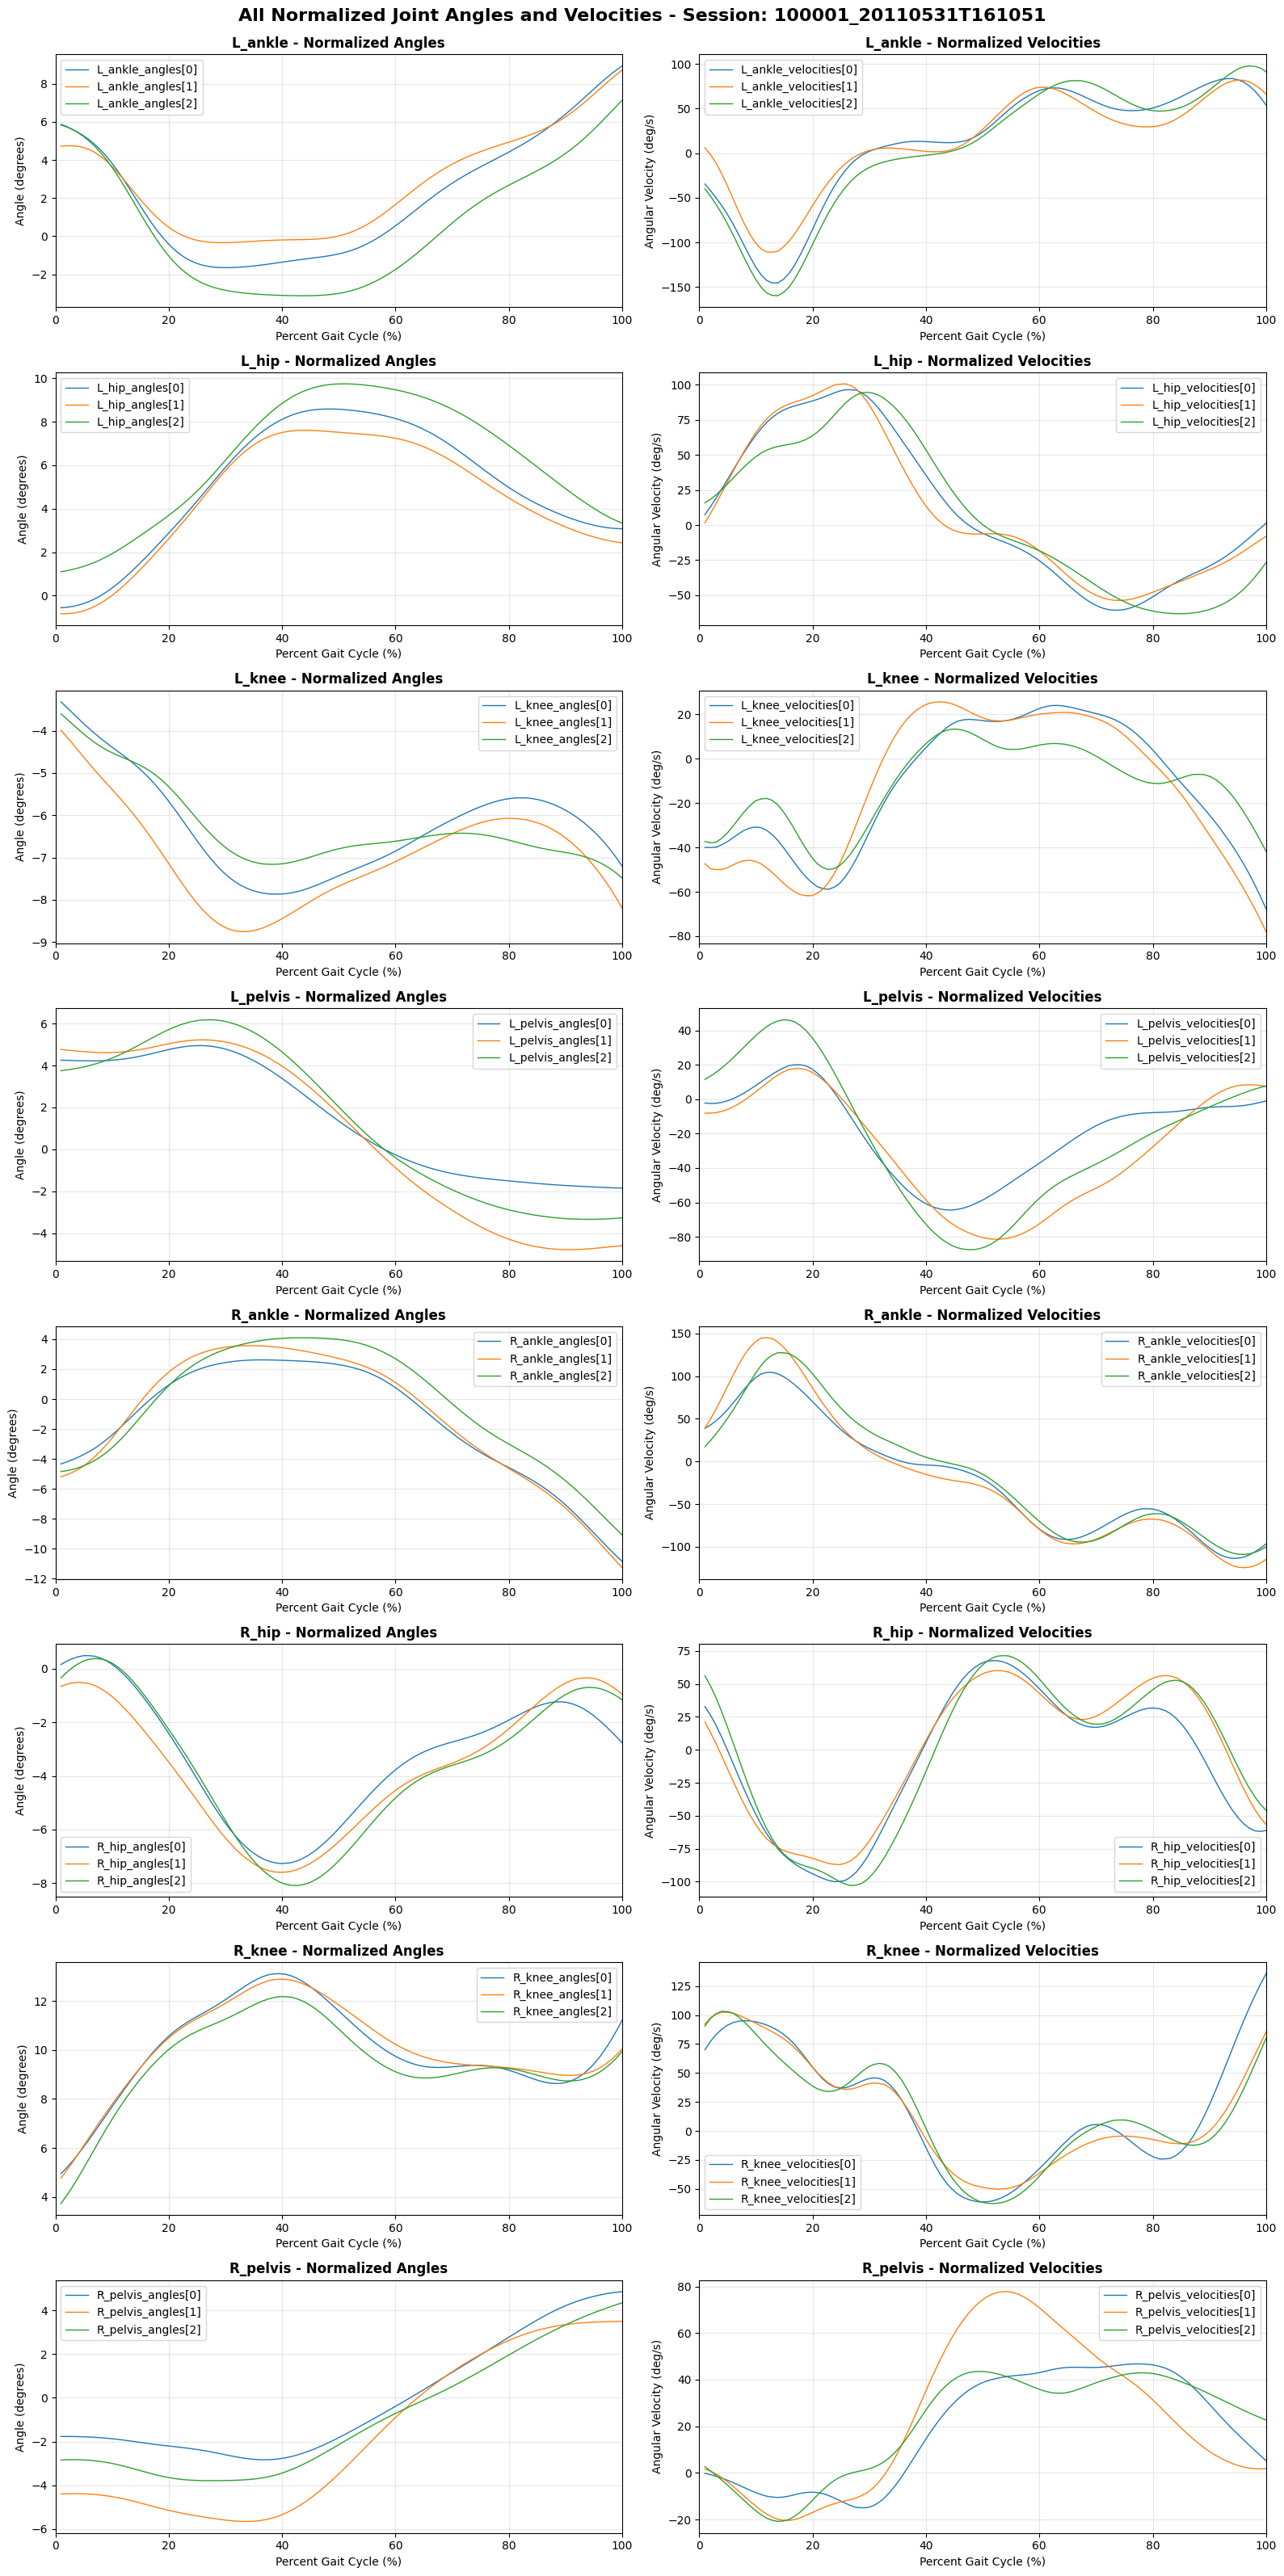

In [8]:
common_joints_sorted = sorted(common_joints)

ts = ktk.TimeSeries()


first_joint = common_joints_sorted[0]
time_array = normalized_angles[first_joint]['PercentGaitCycle'].values
ts.time = time_array

for joint in common_joints_sorted:
    angle_data = normalized_angles[joint]
    velocity_data = normalized_velocities[joint]
    
    angle_values = angle_data[['X_deg', 'Y_deg', 'Z_deg']].values
    ts = ts.add_data(f"{joint}_angles", angle_values)
    
    velocity_values = velocity_data[['X_deg_per_s', 'Y_deg_per_s', 'Z_deg_per_s']].values
    ts = ts.add_data(f"{joint}_velocities", velocity_values)

n_joints = len(common_joints_sorted)
fig, axes = plt.subplots(n_joints, 2, figsize=(16, 4 * n_joints))

# Handle case where we have only one joint
if n_joints == 1:
    axes = axes.reshape(1, -1)

for i, joint in enumerate(common_joints_sorted):
    # Plot angles (left column)
    plt.subplot(n_joints, 2, 2*i + 1)
    ts.plot(f"{joint}_angles")
    plt.title(f'{joint} - Normalized Angles', fontsize=12, fontweight='bold')
    plt.xlabel('Percent Gait Cycle (%)')
    plt.ylabel('Angle (degrees)')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 100)
    
    # Plot velocities (right column)
    plt.subplot(n_joints, 2, 2*i + 2)
    ts.plot(f"{joint}_velocities")
    plt.title(f'{joint} - Normalized Velocities', fontsize=12, fontweight='bold')
    plt.xlabel('Percent Gait Cycle (%)')
    plt.ylabel('Angular Velocity (deg/s)')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 100)

plt.suptitle(f'All Normalized Joint Angles and Velocities - Session: {first_session_id}', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [9]:
for joint in common_joints_sorted:
    angle_data = normalized_angles[joint]
    velocity_data = normalized_velocities[joint]
    
    print(f"\n{joint}:")
    print(f"  Angle data shape: {angle_data.shape}")
    print(f"  Velocity data shape: {velocity_data.shape}")
    print(f"  Angle columns: {list(angle_data.columns)}")
    print(f"  Velocity columns: {list(velocity_data.columns)}")
    
    # Show data ranges
    print(f"  Angle ranges:")
    for col in ['X_deg', 'Y_deg', 'Z_deg']:
        if col in angle_data.columns:
            min_val = angle_data[col].min()
            max_val = angle_data[col].max()
            print(f"    {col}: {min_val:.1f} to {max_val:.1f} degrees")
    
    print(f"  Velocity ranges:")
    for col in ['X_deg_per_s', 'Y_deg_per_s', 'Z_deg_per_s']:
        if col in velocity_data.columns:
            min_val = velocity_data[col].min()
            max_val = velocity_data[col].max()
            print(f"    {col}: {min_val:.1f} to {max_val:.1f} deg/s")



L_ankle:
  Angle data shape: (101, 4)
  Velocity data shape: (101, 4)
  Angle columns: ['PercentGaitCycle', 'X_deg', 'Y_deg', 'Z_deg']
  Velocity columns: ['PercentGaitCycle', 'X_deg_per_s', 'Y_deg_per_s', 'Z_deg_per_s']
  Angle ranges:
    X_deg: -1.7 to 8.9 degrees
    Y_deg: -0.3 to 8.7 degrees
    Z_deg: -3.1 to 7.1 degrees
  Velocity ranges:
    X_deg_per_s: -145.3 to 83.6 deg/s
    Y_deg_per_s: -110.8 to 82.0 deg/s
    Z_deg_per_s: -159.6 to 97.8 deg/s

L_hip:
  Angle data shape: (101, 4)
  Velocity data shape: (101, 4)
  Angle columns: ['PercentGaitCycle', 'X_deg', 'Y_deg', 'Z_deg']
  Velocity columns: ['PercentGaitCycle', 'X_deg_per_s', 'Y_deg_per_s', 'Z_deg_per_s']
  Angle ranges:
    X_deg: -0.6 to 8.6 degrees
    Y_deg: -0.8 to 7.6 degrees
    Z_deg: 1.1 to 9.7 degrees
  Velocity ranges:
    X_deg_per_s: -60.7 to 96.5 deg/s
    Y_deg_per_s: -53.7 to 100.7 deg/s
    Z_deg_per_s: -63.2 to 94.6 deg/s

L_knee:
  Angle data shape: (101, 4)
  Velocity data shape: (101, 4)
  Angle

In [10]:
import matplotlib

loader = MatlabDataLoader()

SCALING_FACTOR = 350
OFFSET = [1, 0, 1]
marker_ts = ktk.TimeSeries()

# Use TimeIndex values as time
sampling_rate = loader.get_discrete_variables()["Hz"].values[0]
time_array = (l_shank_1_marker_data['TimeIndex'].values - 1) / int(sampling_rate)
marker_ts.time = time_array

all_markers = loader.get_available_markers(first_session_id)

for marker_key in all_markers:
    print("Including marker: ", marker_key)
    marker_df = loader.get_marker_data(first_session_id, marker_key)
    marker_positions_3d = (marker_df[['X_coord', 'Y_coord', 'Z_coord']].values / SCALING_FACTOR) + OFFSET
    marker_positions_4d = np.column_stack([marker_positions_3d, np.ones(marker_positions_3d.shape[0])])
    marker_ts = marker_ts.add_data(marker_key, marker_positions_4d)

Including marker:  L_foot_1
Including marker:  L_foot_2
Including marker:  L_foot_3
Including marker:  L_foot_4
Including marker:  L_shank_1
Including marker:  L_shank_2
Including marker:  L_shank_3
Including marker:  L_shank_4
Including marker:  L_thigh_1
Including marker:  L_thigh_2
Including marker:  L_thigh_3
Including marker:  L_thigh_4
Including marker:  L_toe
Including marker:  R_foot_1
Including marker:  R_foot_2
Including marker:  R_foot_3
Including marker:  R_foot_4
Including marker:  R_shank_1
Including marker:  R_shank_2
Including marker:  R_shank_3
Including marker:  R_shank_4
Including marker:  R_thigh_1
Including marker:  R_thigh_2
Including marker:  R_thigh_3
Including marker:  R_thigh_4
Including marker:  R_toe
Including marker:  pelvis_1
Including marker:  pelvis_2
Including marker:  pelvis_3
Including marker:  pelvis_4


In [11]:
interconnections = {
    "L_foot": {
        "Color": "b",
        "Links": [
            ["L_foot_1", "L_foot_2", "L_foot_3", "L_foot_1"],
            ["L_foot_1", "L_foot_4"],
            ["L_foot_2", "L_foot_4"],
            ["L_foot_3", "L_foot_4"],
            ["L_toe", "L_foot_3"],
            ["L_toe", "L_foot_2"],
            ["L_toe", "L_foot_1"],
        ],
    },
    "R_foot": {
        "Color": "r",
        "Links": [
            ["R_foot_1", "R_foot_2", "R_foot_3", "R_foot_1"],
            ["R_foot_1", "R_foot_4"],
            ["R_foot_2", "R_foot_4"],
            ["R_foot_3", "R_foot_4"],
            ["R_toe", "R_foot_3"],
            ["R_toe", "R_foot_2"],
            ["R_toe", "R_foot_1"],
        ],
    },
    "L_shank": {
        "Color": "g",
        "Links": [
            ["L_shank_1", "L_shank_2", "L_shank_3", "L_shank_4", "L_shank_1"],
        ],
    },
    "R_shank": {
        "Color": (1, 0.5, 0),
        "Links": [
            ["R_shank_1", "R_shank_2", "R_shank_3", "R_shank_4", "R_shank_1"],
        ],
    },
    "legs": {
        "Color": "w",
        "Links": [
            ["L_shank_3", "L_foot_1", "L_shank_4"],
            ["R_shank_3", "R_foot_1", "R_shank_4"],
        ],
    },
     "quads": {
        "Color": "w",
        "Links": [
            ["L_thigh_3", "L_shank_1"],
            ["L_thigh_4", "L_shank_2"],
            ["R_thigh_3", "R_shank_1"],
            ["R_thigh_4", "R_shank_2"],
            ["L_thigh_1", "pelvis_3"],
            ["L_thigh_2", "pelvis_1"],
            ["R_thigh_1", "pelvis_3"],
            ["R_thigh_2", "pelvis_2"],
        ],
    },
    "L_thigh": {
        "Color": (0.5, 0, 0.9),
        "Links": [
            ["L_thigh_1", "L_thigh_2", "L_thigh_3", "L_thigh_4", "L_thigh_1"],
        ],
    },
    "R_thigh": {
        "Color": (0, 1, 1),
        "Links": [
            ["R_thigh_1", "R_thigh_2", "R_thigh_3", "R_thigh_4", "R_thigh_1"],
        ],
    },
    "pelvis": {
        "Color": (1, 1, 0),
        "Links": [
            ["pelvis_1", "pelvis_2", "pelvis_3", "pelvis_1"],
            ["pelvis_4", "pelvis_1"],
            ["pelvis_4", "pelvis_2"],
            ["pelvis_4", "pelvis_3"],
        ],
    }
}

In [12]:
original_backend = matplotlib.get_backend()

In [ ]:
# to reproduce the player matplot lib needs to run as a interactive backend
# uncomment the next lines to reproduce the player.
%matplotlib qt5
visualize_marker_trajectories(marker_ts)

The player requires a interactive backend, please run the following command:
%matplotlib qt5


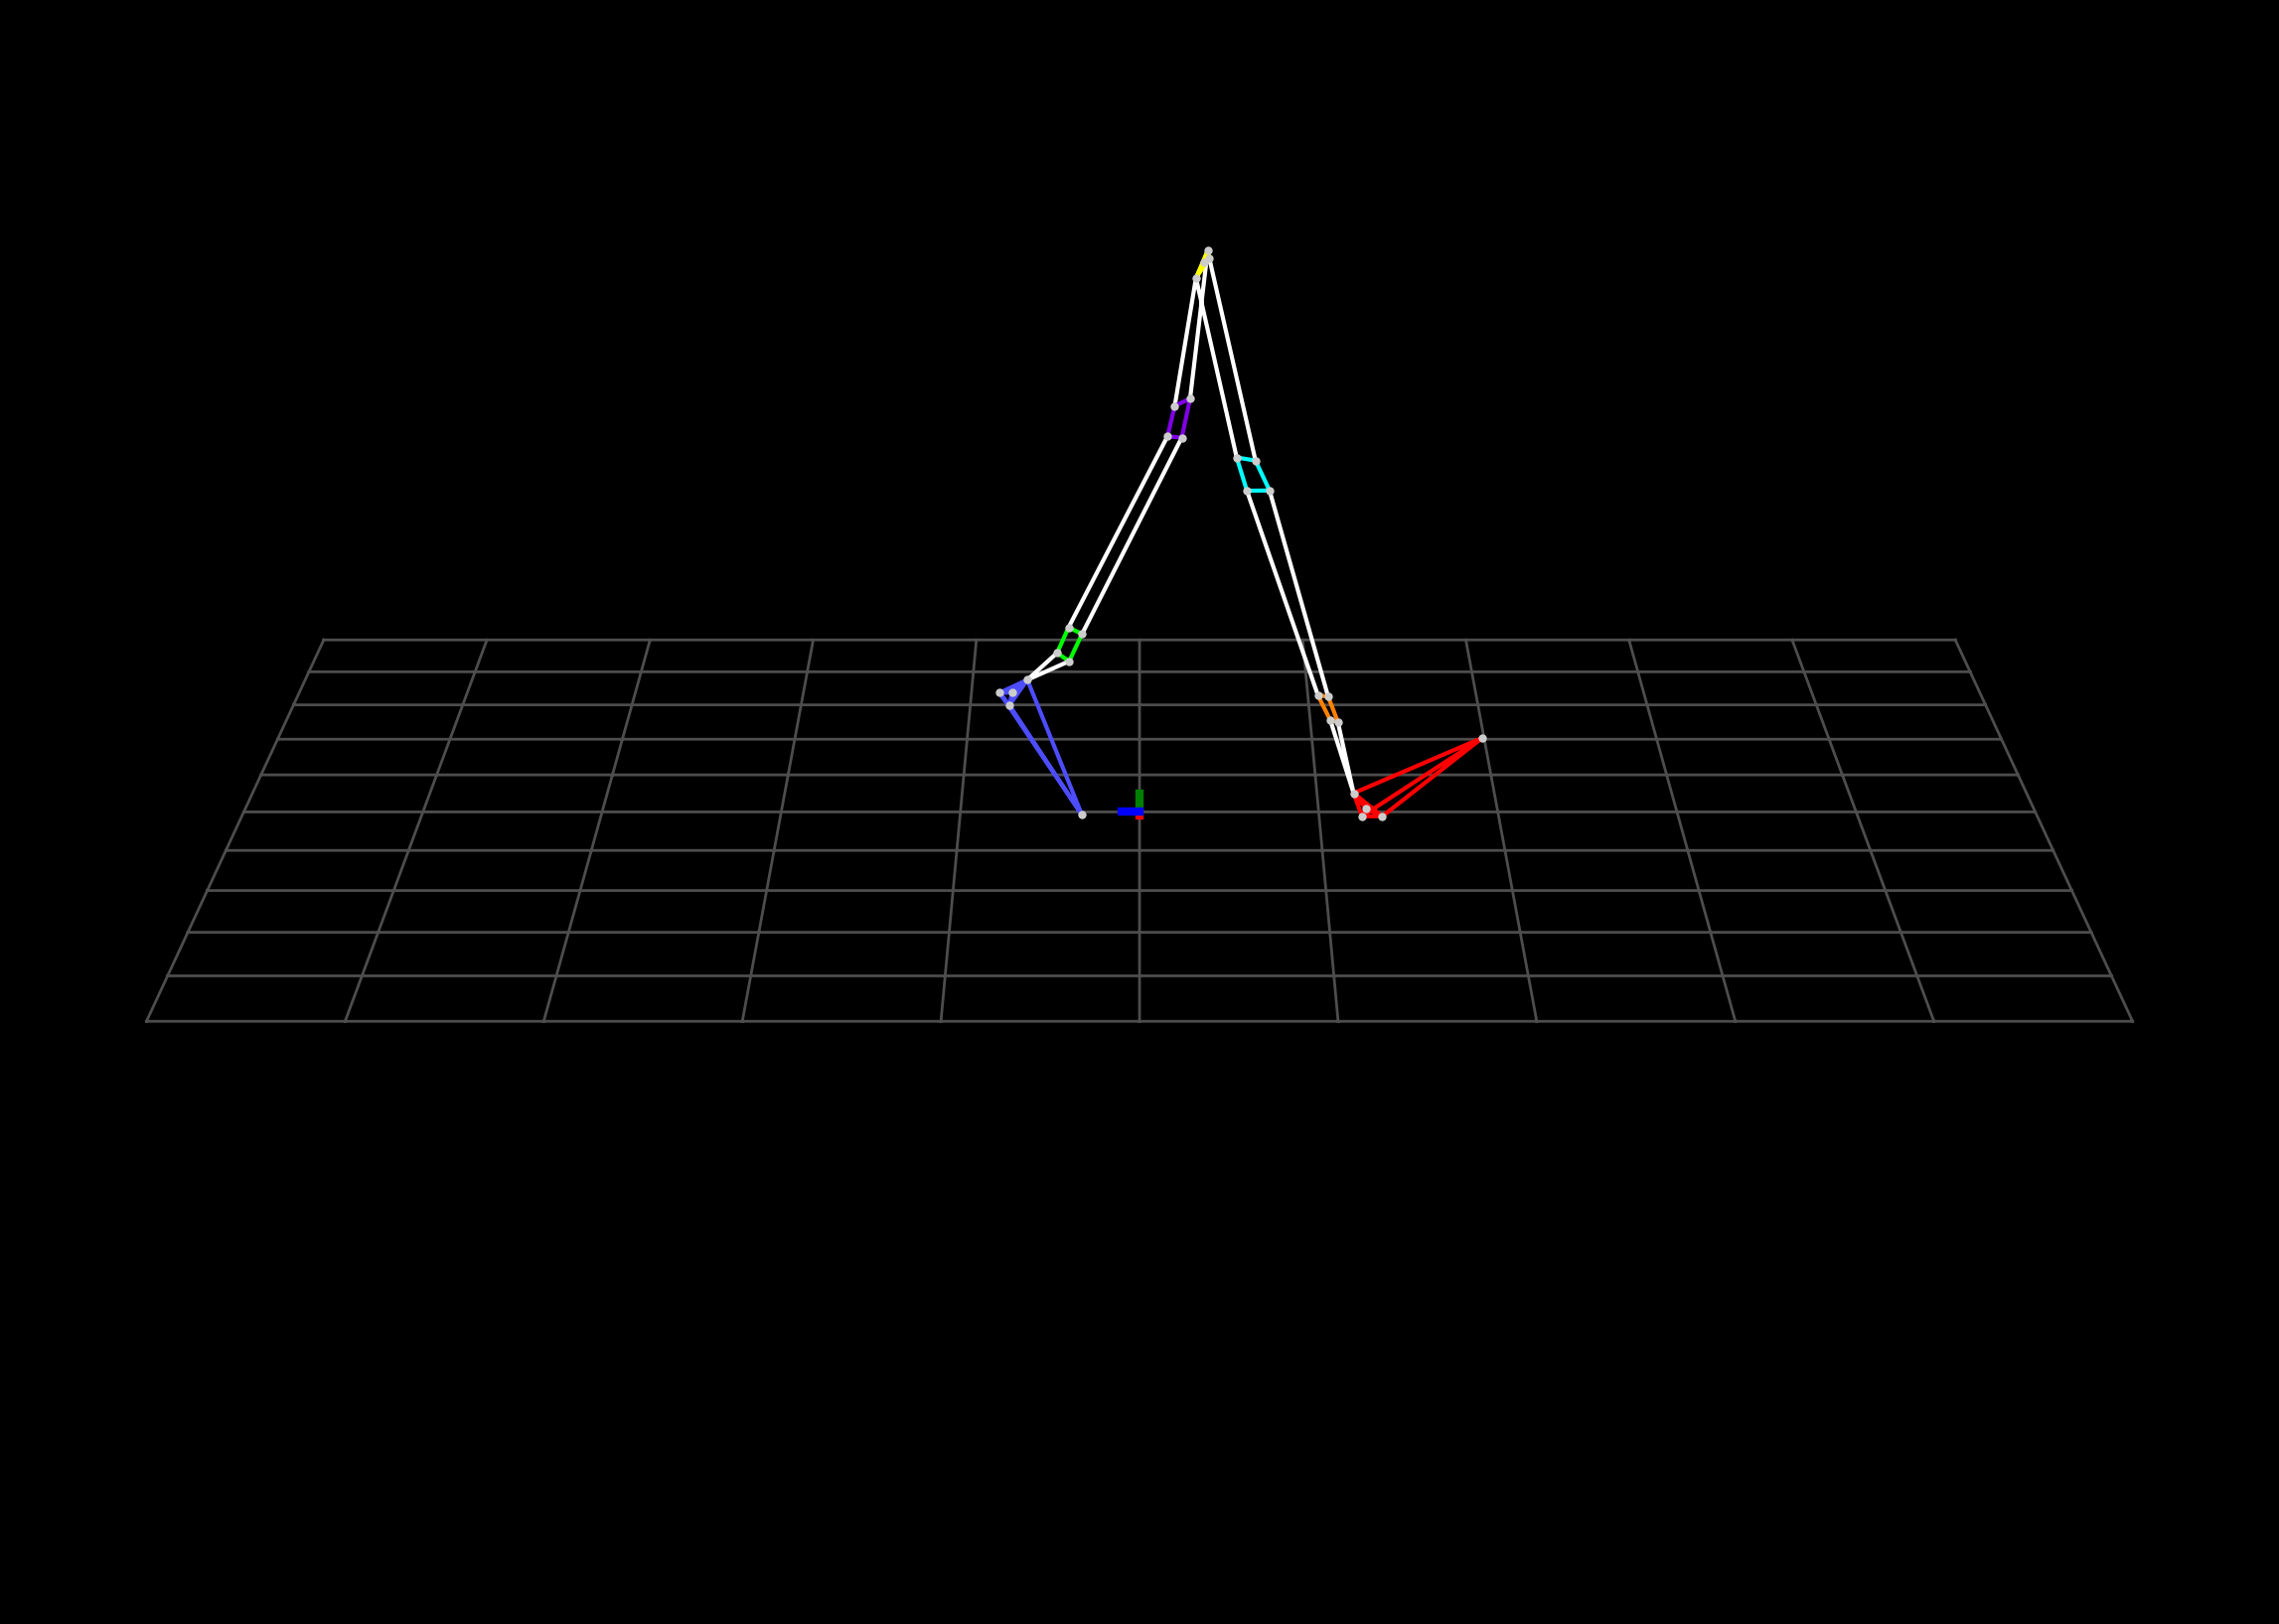

In [14]:
matplotlib.pyplot.switch_backend(original_backend)
plt.show()  # To purge the player frame